In [7]:
import sys
sys.path.append(r"C:\Users\User\Downloads\cds\CDS")
import os
import re
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from unidecode import unidecode
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from src.models.image.resnet import ResNet50
from src.utils import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# =====================
# Label setup
# =====================
train_metadata_csv = r"C:\Users\User\Downloads\cds\CDS\processed_train_metadata.csv"
test_metadata_csv  = r"C:\Users\User\Downloads\cds\CDS\processed_test_metadata.csv"

train_df = pd.read_csv(train_metadata_csv)[["video_id", "utterance", "emotion"]]
test_df  = pd.read_csv(test_metadata_csv)[["video_id", "utterance", "emotion"]]

label_list = sorted(train_df["emotion"].unique())
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}

train_df["label"] = train_df["emotion"].map(label2id)
test_df["label"]  = test_df["emotion"].map(label2id)

# =====================
# Text cleaning
# =====================
def clean_utterance(text):
    text = str(text)
    text = text.replace("‘", "'").replace("’", "'").replace("ʼ", "'").replace("′", "'")
    text = text.replace("“", '"').replace("”", '"').replace("„", '"').replace("‟", '"')
    text = text.replace("…", "...").replace("⋯", "...")
    text = text.replace("—", "-").replace("–", "-").replace("‒", "-").replace("‑", "-")
    text = text.replace(" ", " ").replace(" ", " ")
    text = unidecode(text)
    text = re.sub(r"[^\x00-\x7F]+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# =====================
# Multimodal Dataset
# =====================
class MultimodalDataset(Dataset):
    def __init__(self, df, frames_root, audio_root, tokenizer, image_transform,
                 n_frames=8, max_len=128, n_mels=64, mel_width=128):
        self.tokenizer       = tokenizer
        self.image_transform = image_transform
        self.n_frames        = n_frames
        self.max_len         = max_len
        self.n_mels          = n_mels
        self.mel_width       = mel_width

        records = []
        for _, row in df.iterrows():
            vid        = row["video_id"]
            frame_dir  = os.path.join(frames_root, vid)
            audio_path = os.path.join(audio_root, vid + ".wav")
            if not os.path.isdir(frame_dir) or len(os.listdir(frame_dir)) == 0:
                continue
            if not os.path.exists(audio_path):
                continue
            records.append({
                "utterance":  clean_utterance(row["utterance"]),
                "label":      row["label"],
                "frame_dir":  frame_dir,
                "audio_path": audio_path,
            })
        self.records = records

    def __len__(self):
        return len(self.records)

    def _load_frames(self, frame_dir):
        frames  = sorted(os.listdir(frame_dir))
        total   = len(frames)
        indices = np.linspace(0, total - 1, self.n_frames).astype(int)
        indices = np.clip(indices, 0, total - 1)
        images  = []
        for i in indices:
            img = Image.open(os.path.join(frame_dir, frames[i])).convert("RGB")
            if self.image_transform:
                img = self.image_transform(img)
            images.append(img)
        return torch.stack(images)

    def _load_audio(self, audio_path):
        y, sr    = librosa.load(audio_path, sr=16000, mono=True)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=self.n_mels)
        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        mel_t    = torch.from_numpy(mel_spec.astype(np.float32)).unsqueeze(0)
        if mel_t.shape[-1] < self.mel_width:
            mel_t = nn.functional.pad(mel_t, (0, self.mel_width - mel_t.shape[-1]))
        else:
            mel_t = mel_t[..., :self.mel_width]
        return mel_t

    def __getitem__(self, idx):
        rec   = self.records[idx]
        enc   = self.tokenizer(
            rec["utterance"], truncation=True, padding="max_length",
            max_length=self.max_len, return_tensors="pt"
        )
        frames = self._load_frames(rec["frame_dir"])
        mel    = self._load_audio(rec["audio_path"])
        label  = torch.tensor(rec["label"], dtype=torch.long)
        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0), frames, mel, label

In [9]:
# =====================
# Text encoder
# =====================
class TextEncoder(nn.Module):
    def __init__(self, checkpoint_path):
        super().__init__()
        full_model    = AutoModelForSequenceClassification.from_pretrained(checkpoint_path)
        self.bert     = full_model.bert
        for p in self.bert.parameters():
            p.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state[:, 0, :]  

# =====================
# Image encoder
# =====================
class ImageEncoder(nn.Module):
    def __init__(self, weights_path, num_classes=7):
        super().__init__()
        model = ResNet50(num_classes=num_classes)
        model.load_state_dict(torch.load(weights_path, map_location="cpu"))
        model.fc = nn.Identity()
        self.model = model
        for p in self.model.parameters():
            p.requires_grad = False

    def forward(self, frames):
        return self.model(frames)  

# =====================
# Audio encoder
# =====================
class AudioCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

class AudioEncoder(nn.Module):
    def __init__(self, weights_path, num_classes=7):
        super().__init__()
        cnn           = AudioCNN(num_classes=num_classes)
        cnn.load_state_dict(torch.load(weights_path, map_location="cpu"))
        self.features = cnn.features
        self.pool     = cnn.pool
        self.flatten  = nn.Flatten()
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, mel):
        x = self.features(mel)
        x = self.pool(x)
        return self.flatten(x)  

In [10]:
# =====================
# Early fusion model
# =====================
class EarlyFusionModel(nn.Module):
    def __init__(self, text_enc, image_enc, audio_enc, num_classes=7):
        super().__init__()
        self.text_enc   = text_enc
        self.image_enc  = image_enc
        self.audio_enc  = audio_enc
        self.classifier = nn.Sequential(
            nn.Linear(768 + 2048 + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def train(self, mode=True):
        super().train(mode)
        self.text_enc.eval()
        self.image_enc.eval()
        self.audio_enc.eval()
        return self

    def forward(self, input_ids, attention_mask, frames, mel):
        text_feat  = self.text_enc(input_ids, attention_mask)
        image_feat = self.image_enc(frames)
        audio_feat = self.audio_enc(mel)
        fused      = torch.cat([text_feat, image_feat, audio_feat], dim=1)
        return self.classifier(fused)

In [11]:
# =====================
# Tokenizer + transforms
# =====================
tokenizer = AutoTokenizer.from_pretrained("bhadresh-savani/bert-base-uncased-emotion")

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# =====================
# Datasets
# =====================
train_frames_root = r"C:\Users\User\Downloads\cds\CDS\processed_train_frames"
test_frames_root  = r"C:\Users\User\Downloads\cds\CDS\processed_test_frames"
train_audio_dir   = r"C:\Users\User\Downloads\cds\CDS\processed_train_audio"
test_audio_dir    = r"C:\Users\User\Downloads\cds\CDS\processed_test_audio"

full_train_dataset = MultimodalDataset(
    train_df, train_frames_root, train_audio_dir, tokenizer, image_transform
)
test_dataset = MultimodalDataset(
    test_df, test_frames_root, test_audio_dir, tokenizer, image_transform
)

from torch.utils.data import random_split
val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# =====================
# DataLoaders
# =====================
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

# =====================
# Class weights 
# =====================
train_labels  = [r["label"] for r in full_train_dataset.records]
class_weights = compute_class_weight("balanced", classes=np.arange(len(label_list)), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [12]:
# =====================
# Build model
# =====================
checkpoint_path     = r"C:\Users\User\Downloads\cds\CDS\text_checkpoint\checkpoint-2500"
image_weights_path  = r"C:\Users\User\Downloads\cds\CDS\resnet_model_weights_extracted.pth"
audio_weights_path  = r"C:\Users\User\Downloads\cds\CDS\audio_model_weights.pth"
fusion_weights_path = r"C:\Users\User\Downloads\cds\CDS\early_fusion_weights.pth"

text_enc  = TextEncoder(checkpoint_path)
image_enc = ImageEncoder(image_weights_path, num_classes=len(label_list))
audio_enc = AudioEncoder(audio_weights_path, num_classes=len(label_list))

model = EarlyFusionModel(text_enc, image_enc, audio_enc, num_classes=len(label_list)).to(device)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=class_weights)

best_val_loss            = float("inf")
no_improve               = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(20):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for input_ids, attention_mask, frames, mel, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/20"):
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        frames, mel, labels       = frames.to(device), mel.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, frames, mel)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # =====================
    # Validation — uses val_loader 
    # =====================
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for input_ids, attention_mask, frames, mel, labels in val_loader:
            input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
            frames, mel, labels       = frames.to(device), mel.to(device), labels.to(device)
            logits      = model(input_ids, attention_mask, frames, mel)
            loss        = criterion(logits, labels)
            val_loss   += loss.item()
            preds       = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve    = 0
        torch.save(model.state_dict(), fusion_weights_path)
    else:
        no_improve += 1
        if no_improve >= 5:
            print("Early stopping.")
            break


Epoch 1/20:  35%|███▌      | 59/168 [01:34<02:40,  1.48s/it]c:\Users\User\Downloads\cds\venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1365
  warnings.warn(
Epoch 1/20:  74%|███████▍  | 124/168 [03:11<01:06,  1.50s/it]c:\Users\User\Downloads\cds\venv\lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1024
  warnings.warn(
Epoch 1/20: 100%|██████████| 168/168 [04:17<00:00,  1.53s/it]


Epoch 1 | Train Loss: 1.8983  Acc: 0.3317 | Val Loss: 1.1667  Acc: 0.7299


Epoch 2/20: 100%|██████████| 168/168 [04:14<00:00,  1.52s/it]


Epoch 2 | Train Loss: 1.2015  Acc: 0.5750 | Val Loss: 0.8635  Acc: 0.6299


Epoch 3/20: 100%|██████████| 168/168 [15:28<00:00,  5.53s/it]


...

Epoch 18 | Train Loss: 0.7983  Acc: 0.7235 | Val Loss: 0.6343  Acc: 0.8388


Epoch 19/20: 100%|██████████| 168/168 [15:06<00:00,  5.40s/it]


Epoch 19 | Train Loss: 0.8016  Acc: 0.7321 | Val Loss: 0.6189  Acc: 0.8373


Epoch 20/20: 100%|██████████| 168/168 [12:53<00:00,  4.60s/it]


Epoch 20 | Train Loss: 0.7786  Acc: 0.7317 | Val Loss: 0.5988  Acc: 0.8448
Early stopping.


In [13]:
# Load best model
model.load_state_dict(torch.load(fusion_weights_path, map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for input_ids, attention_mask, frames, mel, labels in tqdm(test_loader, desc="Evaluating"):
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        frames, mel               = frames.to(device), mel.to(device)
        logits = model(input_ids, attention_mask, frames, mel)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

evaluate(all_labels, all_preds)

Evaluating: 100%|██████████| 164/164 [13:24<00:00,  4.91s/it]

Validation Accuracy: 0.5923
Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.45      0.44       345
           1       0.43      0.22      0.29        68
           2       0.21      0.30      0.25        50
           3       0.59      0.55      0.57       402
           4       0.76      0.71      0.74      1256
           5       0.30      0.36      0.32       208
           6       0.49      0.63      0.55       281

    accuracy                           0.59      2610
   macro avg       0.46      0.46      0.45      2610
weighted avg       0.61      0.59      0.60      2610

Confusion Matrix:
[[154   9  14  36  57  31  44]
 [ 12  15   2   2  22   8   7]
 [  4   0  15   1  15   8   7]
 [ 32   1   5 221  89  15  39]
 [ 97   7  23  71 891 103  64]
 [ 28   2   9  12  63  74  20]
 [ 31   1   3  29  30  11 176]]


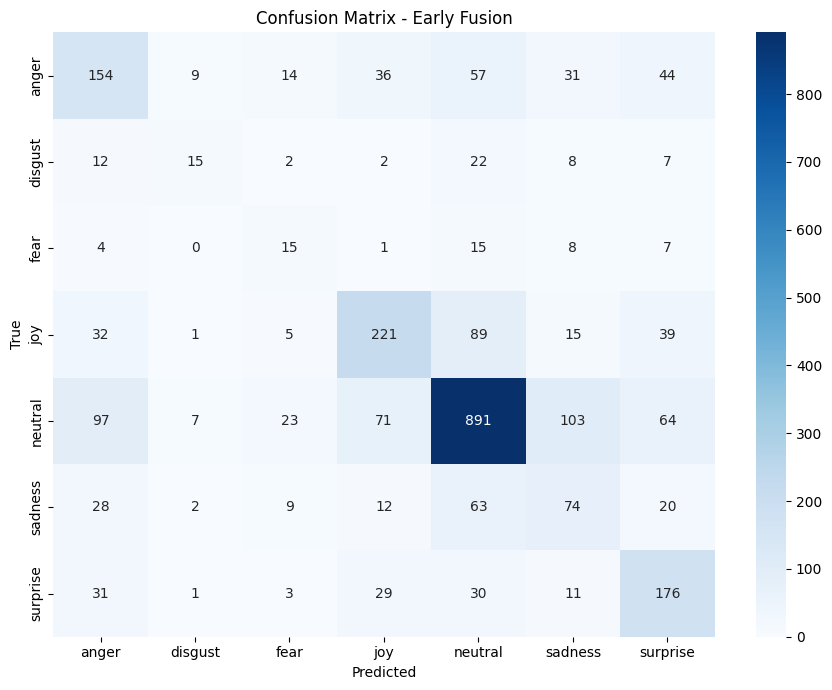

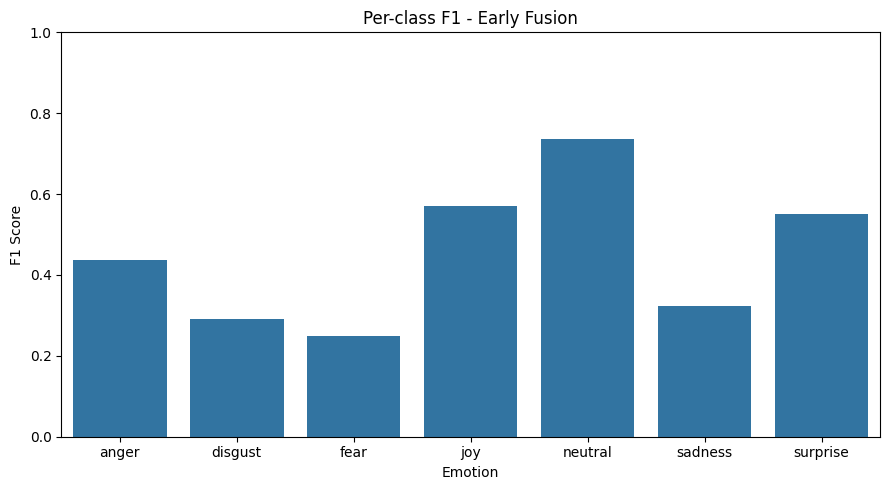

In [14]:
# =====================
# Confusion matrix
# =====================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_list, yticklabels=label_list)
plt.title("Confusion Matrix - Early Fusion")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# =====================
# Per-class F1
# =====================
report    = classification_report(all_labels, all_preds, target_names=label_list, output_dict=True)
f1_scores = [report[l]["f1-score"] for l in label_list]

plt.figure(figsize=(9, 5))
sns.barplot(x=label_list, y=f1_scores)
plt.title("Per-class F1 - Early Fusion")
plt.xlabel("Emotion")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()